# Marketing A/B Testing: Statistical Evaluation of Campaign Performance

**Author:** Sanan Mammadov  
**Date:** 2026-04-20  
**Dataset:** Control Group & Test Group — 30-day parallel marketing campaigns

---

## 1. Executive Summary

This notebook presents a rigorous statistical evaluation of a marketing A/B test comparing a **Control Campaign** against a **Test Campaign** across a full user acquisition funnel.

The analysis follows a structured pipeline:

1. Data ingestion, schema validation, and preprocessing
2. Exploratory Data Analysis (EDA) of spend, impressions, and distributions
3. Derivation of five funnel KPIs: CTR, Add-to-Cart Rate, Conversion Rate, CPC, and CPP
4. Normality testing (Shapiro-Wilk) to select the correct hypothesis test
5. Variance homogeneity assessment (Levene's Test)
6. Non-parametric hypothesis testing (Mann-Whitney U) at α = 0.05
7. Effect size quantification (Rank-Biserial Correlation) and Bootstrap 95% CIs
8. Funnel drop-off analysis and strategic business recommendations

> **Bottom line:** The Test campaign significantly improves top and mid-funnel metrics (CTR and Add-to-Cart Rate), but does **not** improve final Conversion Rate or cost efficiency. Budget scaling is not yet justified.

## 2. Environment Setup & Dependencies

All imports are consolidated here following standard engineering practice. This makes the dependency surface immediately visible and prevents scattered import errors mid-notebook.

In [4]:
# Standard Library
from datetime import datetime
import warnings

# Third-Party: Data
import numpy as np
import pandas as pd

# Third-Party: Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Third-Party: Statistics
import scipy.stats as st
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower

# ── Global plot style ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold',
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# ── Reproducibility seed ──────────────────────────────────────────────────
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Significance level ────────────────────────────────────────────────────
ALPHA = 0.05

# Scope warnings narrowly — we still want to SEE SciPy warnings about ties,
# small-sample Shapiro, etc. We only silence the known-harmless seaborn ones.
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

print('Environment ready.')

Environment ready.


## 3. Data Ingestion & Validation

Both CSV files use semicolon delimiters. We load them separately, rename columns to human-readable labels, and validate schemas before merging.

In [7]:
COLS = [
    'Campaign Name', 'Date', 'Spend Amount', 'Number of Impressions',
    'Reach', 'Website Clicks', 'Searches', 'Viewed Content',
    'Added to Cart', 'Purchases'
]

control_raw = pd.read_csv('control_group.csv', delimiter=';')
test_raw    = pd.read_csv('test_group.csv',    delimiter=';')

# Validate the number of columns in the RAW file before we rename.
# (Column names in the source files are inconsistent between the two files,
# so we check shape and then impose a canonical schema.)
assert control_raw.shape[1] == len(COLS), (
    f'Control file has {control_raw.shape[1]} cols, expected {len(COLS)}')
assert test_raw.shape[1]    == len(COLS), (
    f'Test file has {test_raw.shape[1]} cols, expected {len(COLS)}')

control = control_raw.copy()
test    = test_raw.copy()
control.columns = COLS
test.columns    = COLS

print(f'Control rows: {len(control):,}  |  Test rows: {len(test):,}')
control.head()

Control rows: 30  |  Test rows: 30


,Campaign Name,Date,Spend Amount,Number of Impressions,Reach,Website Clicks,Searches,Viewed Content,Added to Cart,Purchases
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Preprocessing

### 4.1 Date Parsing

Dates are stored in day-first format (DD/MM/YYYY). We parse them explicitly to avoid silent misinterpretation.

In [10]:
control['Date'] = pd.to_datetime(control['Date'], dayfirst=True, errors='coerce')
test['Date']    = pd.to_datetime(test['Date'],    dayfirst=True, errors='coerce')

# ── Missing Value Audit ───────────────────────────────────────────────────
print('=== Missing Values — Control ===')
print(control.isnull().sum())

print('\n=== Missing Values — Test ===')
print(test.isnull().sum())

=== Missing Values — Control ===
Campaign Name            0
Date                     0
Spend Amount             0
Number of Impressions    1
Reach                    1
Website Clicks           1
Searches                 1
Viewed Content           1
Added to Cart            1
Purchases                1
dtype: int64

=== Missing Values — Test ===
Campaign Name            0
Date                     0
Spend Amount             0
Number of Impressions    0
Reach                    0
Website Clicks           0
Searches                 0
Viewed Content           0
Added to Cart            0
Purchases                0
dtype: int64


### 4.2 Missing Value Treatment

Only a handful of rows have missing values, and they fall in the numeric funnel columns we depend on downstream. We drop rows missing values in the **columns we actually use** — not every numeric column — so unrelated future columns can't silently nuke the dataset.

Listwise deletion is preferred over mean imputation here because the analysis depends on preserving daily-level variance; imputing a column mean would artificially compress the variance of the affected KPI.

In [13]:
# Columns actually used downstream (funnel volumes + spend)
REQUIRED_COLS = ['Spend Amount', 'Number of Impressions', 'Website Clicks',
                 'Viewed Content', 'Added to Cart', 'Purchases']

n_before = len(control) + len(test)
control = control.dropna(subset=REQUIRED_COLS).reset_index(drop=True)
test    = test.dropna(subset=REQUIRED_COLS).reset_index(drop=True)
n_after = len(control) + len(test)
print(f'Dropped {n_before - n_after} rows with missing values in required columns.')

# Merge into long format
ab_data = (
    pd.concat([control, test], ignore_index=True)
    .sort_values('Date')
    .reset_index(drop=True)
)

print(f'Combined dataset: {len(ab_data):,} rows | '
      f'Date range: {ab_data["Date"].min().date()} → {ab_data["Date"].max().date()}')
print(f'Campaigns: {ab_data["Campaign Name"].unique()}')
ab_data.head()

Dropped 1 rows with missing values in required columns.
Combined dataset: 59 rows | Date range: 2019-08-01 → 2019-08-30
Campaigns: <ArrowStringArray>
['Control Campaign', 'Test Campaign']
Length: 2, dtype: str


,Campaign Name,Date,Spend Amount,Number of Impressions,Reach,Website Clicks,Searches,Viewed Content,Added to Cart,Purchases
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Test Campaign,2019-08-01,3008,39550.0,35820.0,3038.0,1946.0,1069.0,894.0,255.0
2,Test Campaign,2019-08-02,2542,100719.0,91236.0,4657.0,2359.0,1548.0,879.0,677.0
3,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
4,Test Campaign,2019-08-03,2365,70263.0,45198.0,7885.0,2572.0,2367.0,1268.0,578.0


## 5. Exploratory Data Analysis

### 5.1 Spend Analysis

We examine daily spend trajectories and total allocation per campaign to understand whether the two groups had comparable budget exposure — a prerequisite for a valid A/B comparison.

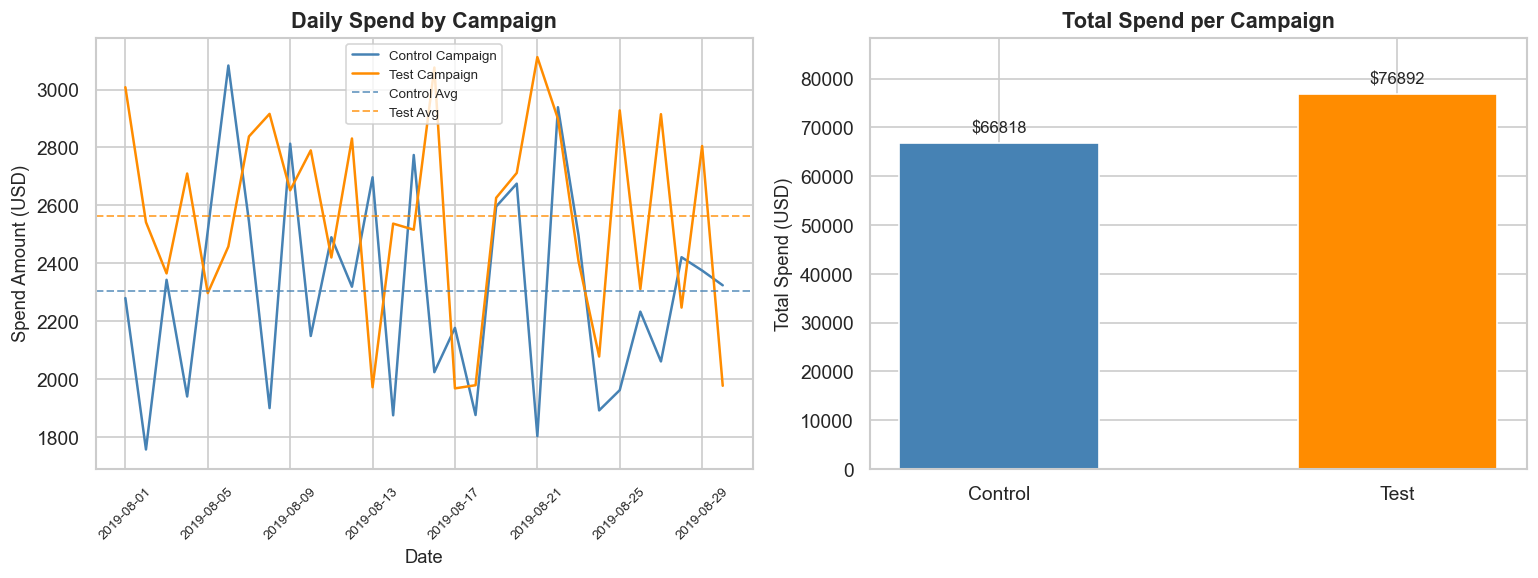

Spend ratio (Test / Control): 1.15x


In [16]:
avg_spend_control = ab_data[ab_data['Campaign Name'] == 'Control Campaign']['Spend Amount'].mean()
avg_spend_test    = ab_data[ab_data['Campaign Name'] == 'Test Campaign']['Spend Amount'].mean()
total_spend_control = ab_data[ab_data['Campaign Name'] == 'Control Campaign']['Spend Amount'].sum()
total_spend_test    = ab_data[ab_data['Campaign Name'] == 'Test Campaign']['Spend Amount'].sum()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(13, 5))

for campaign, color in [('Control Campaign', 'steelblue'), ('Test Campaign', 'darkorange')]:
    subset = ab_data[ab_data['Campaign Name'] == campaign]
    sns.lineplot(data=subset, x='Date', y='Spend Amount', label=campaign, color=color, ax=ax1)

ax1.axhline(avg_spend_control, ls='--', lw=1.2, color='steelblue', alpha=0.7, label='Control Avg')
ax1.axhline(avg_spend_test,    ls='--', lw=1.2, color='darkorange', alpha=0.7, label='Test Avg')
ax1.set_title('Daily Spend by Campaign')
ax1.set_xlabel('Date')
ax1.set_ylabel('Spend Amount (USD)')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=45, labelsize=8)

bars = ax2.bar(['Control', 'Test'], [total_spend_control, total_spend_test],
               color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
ax2.bar_label(bars, fmt='$%.0f', fontsize=10, padding=4)
ax2.set_title('Total Spend per Campaign')
ax2.set_ylabel('Total Spend (USD)')
ax2.set_ylim(0, max(total_spend_control, total_spend_test) * 1.15)

plt.tight_layout()
plt.show()

print(f'Spend ratio (Test / Control): {total_spend_test / total_spend_control:.2f}x')

### 5.2 Impressions Analysis

Impression volume determines the raw exposure each campaign achieved. Large differences here would indicate unequal reach — a confound that must be accounted for before interpreting rate-based KPIs.

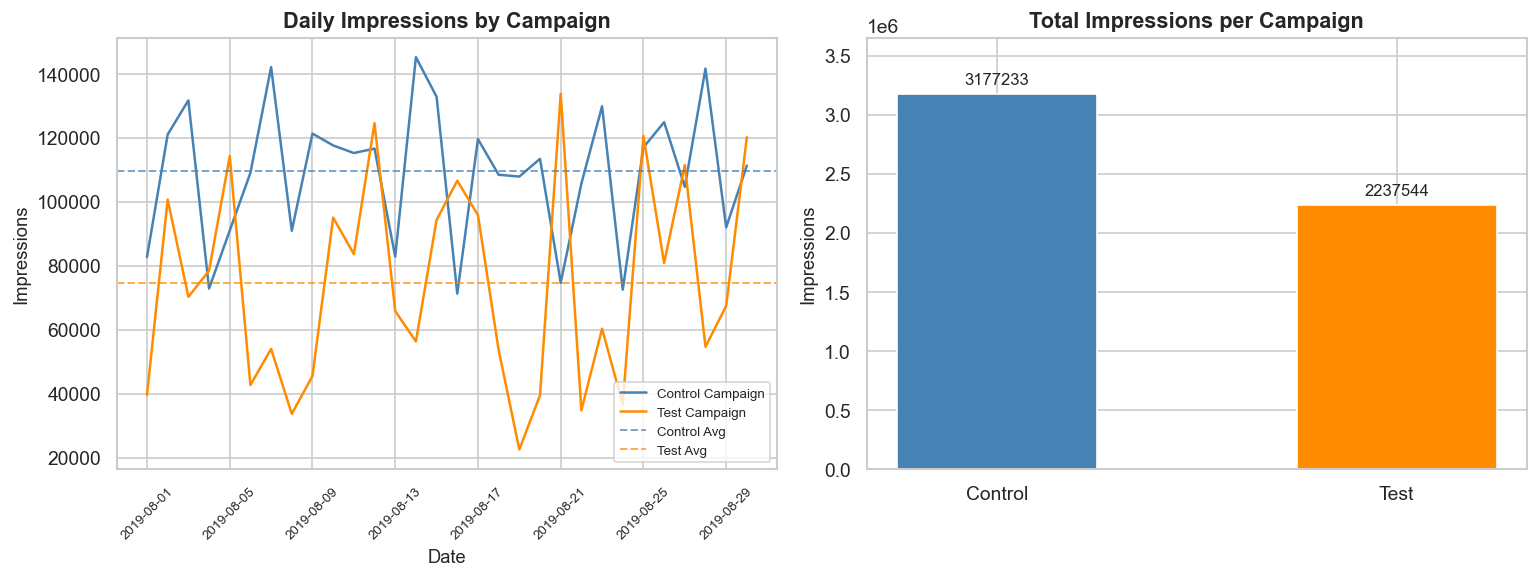

In [19]:
avg_imp_control   = ab_data[ab_data['Campaign Name'] == 'Control Campaign']['Number of Impressions'].mean()
avg_imp_test      = ab_data[ab_data['Campaign Name'] == 'Test Campaign']['Number of Impressions'].mean()
total_imp_control = ab_data[ab_data['Campaign Name'] == 'Control Campaign']['Number of Impressions'].sum()
total_imp_test    = ab_data[ab_data['Campaign Name'] == 'Test Campaign']['Number of Impressions'].sum()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(13, 5))

for campaign, color in [('Control Campaign', 'steelblue'), ('Test Campaign', 'darkorange')]:
    subset = ab_data[ab_data['Campaign Name'] == campaign]
    sns.lineplot(data=subset, x='Date', y='Number of Impressions', label=campaign, color=color, ax=ax1)

ax1.axhline(avg_imp_control, ls='--', lw=1.2, color='steelblue', alpha=0.7, label='Control Avg')
ax1.axhline(avg_imp_test,    ls='--', lw=1.2, color='darkorange', alpha=0.7, label='Test Avg')
ax1.set_title('Daily Impressions by Campaign')
ax1.set_xlabel('Date')
ax1.set_ylabel('Impressions')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=45, labelsize=8)

bars = ax2.bar(['Control', 'Test'], [total_imp_control, total_imp_test],
               color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
ax2.bar_label(bars, fmt='%.0f', fontsize=10, padding=4)
ax2.set_title('Total Impressions per Campaign')
ax2.set_ylabel('Impressions')
ax2.set_ylim(0, max(total_imp_control, total_imp_test) * 1.15)

plt.tight_layout()
plt.show()

### 5.3 Distribution & Outlier Detection

Box plots reveal the spread and skewness of each raw metric per campaign. We follow up with an IQR-based outlier audit **computed within each campaign group separately** — pooling both groups for IQR calculation (a common mistake) would mask campaign-specific distributional differences.

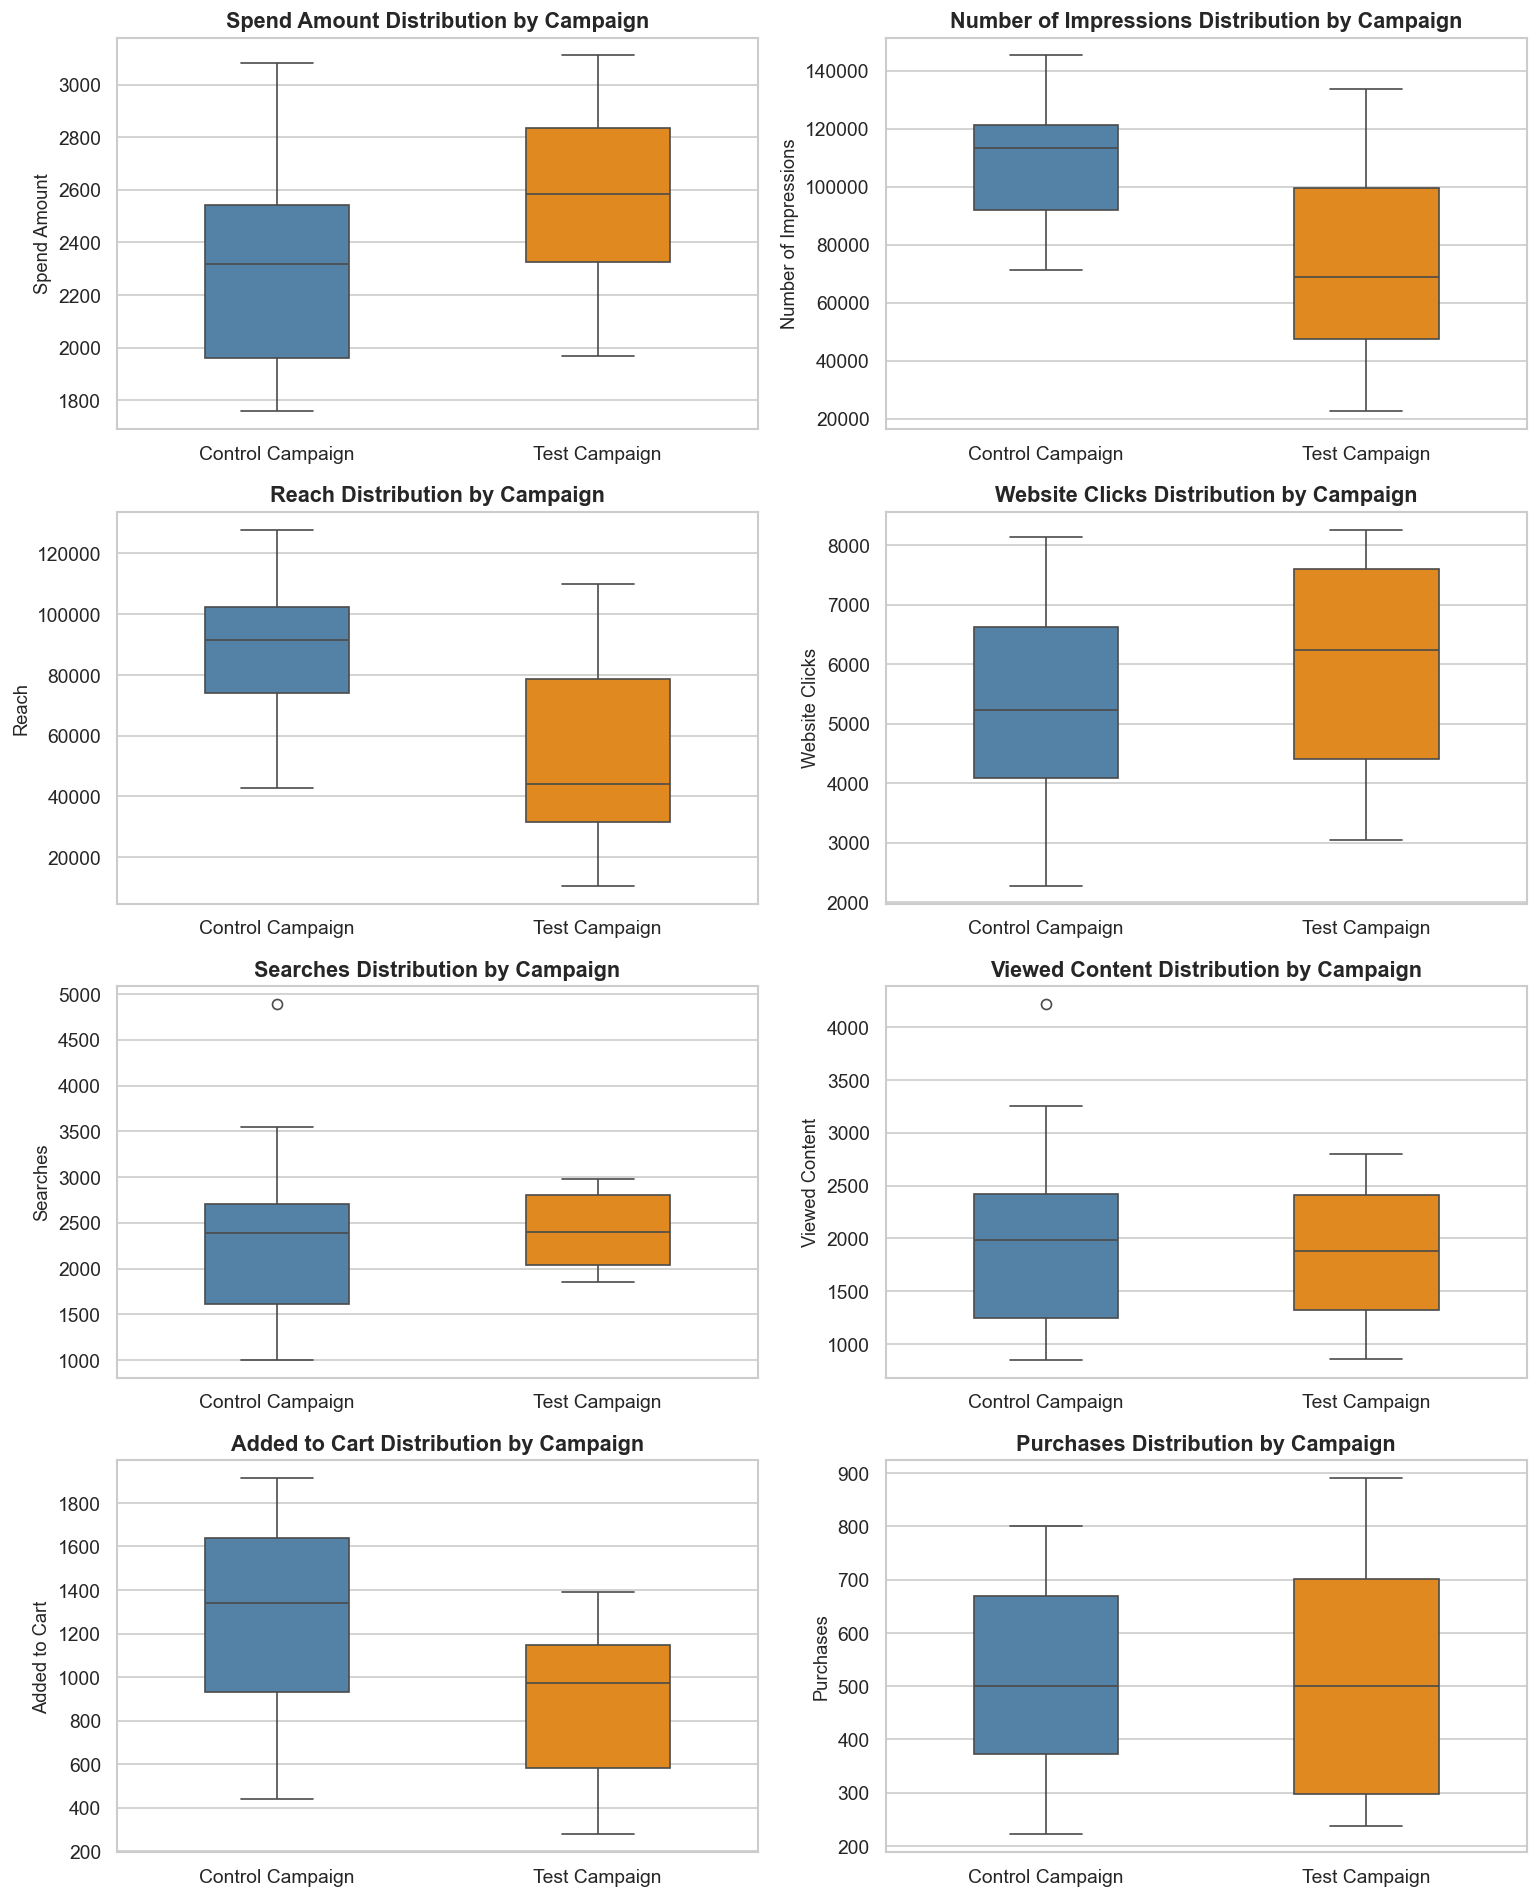

In [22]:
num_cols = ab_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 4))
axes = axes.flatten()

palette = {'Control Campaign': 'steelblue', 'Test Campaign': 'darkorange'}

for i, col in enumerate(num_cols):
    sns.boxplot(data=ab_data, x='Campaign Name', y=col,
                hue='Campaign Name', palette=palette,
                width=0.45, legend=False, ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Campaign')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
# Outlier detection computed WITHIN each campaign group (not pooled)
outlier_records = []

for campaign in ab_data['Campaign Name'].unique():
    df_campaign = ab_data[ab_data['Campaign Name'] == campaign]
    for col in num_cols:
        Q1  = df_campaign[col].quantile(0.25)   # per-campaign IQR
        Q3  = df_campaign[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df_campaign[(df_campaign[col] < Q1 - 1.5 * IQR) |
                               (df_campaign[col] > Q3 + 1.5 * IQR)]
        pct = len(outliers) / len(df_campaign) * 100
        rec = ('Keep' if pct < 5
               else 'Review / cap' if pct < 10
               else 'Investigate / remove')
        outlier_records.append({'Campaign': campaign, 'Feature': col,
                                'Outlier Count': len(outliers),
                                'Outlier %': round(pct, 1),
                                'Recommendation': rec})

outlier_df = pd.DataFrame(outlier_records)
print(outlier_df.to_string(index=False))

        Campaign               Feature  Outlier Count  Outlier % Recommendation
Control Campaign          Spend Amount              0        0.0           Keep
Control Campaign Number of Impressions              0        0.0           Keep
Control Campaign                 Reach              0        0.0           Keep
Control Campaign        Website Clicks              0        0.0           Keep
Control Campaign              Searches              1        3.4           Keep
Control Campaign        Viewed Content              1        3.4           Keep
Control Campaign         Added to Cart              0        0.0           Keep
Control Campaign             Purchases              0        0.0           Keep
   Test Campaign          Spend Amount              0        0.0           Keep
   Test Campaign Number of Impressions              0        0.0           Keep
   Test Campaign                 Reach              0        0.0           Keep
   Test Campaign        Website Clicks  

## 6. KPI Engineering

We derive five **rate-based KPIs** that normalise for volume and reflect funnel efficiency:

| KPI | Formula | Business Meaning |
|-----|---------|------------------|
| Click-Through Rate (CTR) | Website Clicks / Impressions | Top-of-funnel engagement |
| Add-to-Cart Rate | Added to Cart / Viewed Content | Mid-funnel purchase intent |
| Conversion Rate | Purchases / Website Clicks | Bottom-of-funnel efficiency |
| Cost per Click (CPC) | Spend / Website Clicks | Traffic acquisition cost |
| Cost per Purchase (CPP) | Spend / Purchases | Revenue acquisition cost |

### Two estimators, on purpose

For each rate KPI we keep two views:

- **Per-day KPI** (clicks/impressions *each day*, then aggregated). Good for visualising daily variance and for non-parametric tests over daily observations.
- **Pooled KPI** (total clicks / total impressions across all days — the **ratio of sums**). This is the *unbiased* campaign-level estimator and the one the business actually cares about. Mean-of-ratios is biased whenever daily denominators vary, and would weight a low-impression day the same as a high-impression day.

We also guard explicitly against division by zero so that zero-click or zero-purchase days don't produce silent `inf` values.

In [27]:
# ── Per-day KPIs (for daily-level analysis & visualisation) ──────────────
# Use .where() guards to avoid division by zero producing inf.
def safe_div(num, den):
    return np.where(den > 0, num / den.replace(0, np.nan), np.nan)

ab_data['CTR']              = safe_div(ab_data['Website Clicks'], ab_data['Number of Impressions'])
ab_data['Add_to_Cart_Rate'] = safe_div(ab_data['Added to Cart'],  ab_data['Viewed Content'])
ab_data['Conversion_Rate']  = safe_div(ab_data['Purchases'],       ab_data['Website Clicks'])
ab_data['CostperClick']     = safe_div(ab_data['Spend Amount'],    ab_data['Website Clicks'])
ab_data['CostperPurchase']  = safe_div(ab_data['Spend Amount'],    ab_data['Purchases'])

# Belt-and-braces: scrub any residual inf values from edge cases.
ab_data.replace([np.inf, -np.inf], np.nan, inplace=True)

KPIS = ['CTR', 'Add_to_Cart_Rate', 'Conversion_Rate', 'CostperClick', 'CostperPurchase']
RAW_METRICS = ['Spend Amount', 'Number of Impressions', 'Website Clicks',
               'Viewed Content', 'Added to Cart', 'Purchases']

# Sanity check: any duplicate (campaign, date) pairs?
dupe_mask = ab_data.duplicated(subset=['Campaign Name', 'Date'])
if dupe_mask.any():
    print(f'WARNING: {dupe_mask.sum()} duplicate (campaign, date) rows. '
          'Aggregating volumes with sum, then recomputing KPIs.')
    ab_data = (ab_data.groupby(['Campaign Name', 'Date'], as_index=False)[RAW_METRICS]
                      .sum())
    ab_data['CTR']              = safe_div(ab_data['Website Clicks'], ab_data['Number of Impressions'])
    ab_data['Add_to_Cart_Rate'] = safe_div(ab_data['Added to Cart'],  ab_data['Viewed Content'])
    ab_data['Conversion_Rate']  = safe_div(ab_data['Purchases'],       ab_data['Website Clicks'])
    ab_data['CostperClick']     = safe_div(ab_data['Spend Amount'],    ab_data['Website Clicks'])
    ab_data['CostperPurchase']  = safe_div(ab_data['Spend Amount'],    ab_data['Purchases'])

daily_metrics = ab_data.copy()   # each row is already one (campaign, date)

# ── Pooled (ratio-of-sums) KPIs — the unbiased campaign-level estimator ──
pooled_volumes = ab_data.groupby('Campaign Name')[RAW_METRICS].sum()
pooled_kpis = pd.DataFrame({
    'CTR':              pooled_volumes['Website Clicks']  / pooled_volumes['Number of Impressions'],
    'Add_to_Cart_Rate': pooled_volumes['Added to Cart']   / pooled_volumes['Viewed Content'],
    'Conversion_Rate':  pooled_volumes['Purchases']        / pooled_volumes['Website Clicks'],
    'CostperClick':     pooled_volumes['Spend Amount']     / pooled_volumes['Website Clicks'],
    'CostperPurchase':  pooled_volumes['Spend Amount']     / pooled_volumes['Purchases'],
})

print('=== Pooled (ratio-of-sums) KPIs — unbiased campaign-level estimator ===')
print(pooled_kpis.round(4))

print('\n=== Per-day KPI summary (mean / median / std across days) ===')
summary = daily_metrics.groupby('Campaign Name')[KPIS].agg(['mean', 'median', 'std'])
print(summary.round(4))

=== Pooled (ratio-of-sums) KPIs — unbiased campaign-level estimator ===
                     CTR  Add_to_Cart_Rate  Conversion_Rate  CostperClick  \
Campaign Name                                                               
Control Campaign  0.0486            0.6688           0.0983        0.4330   
Test Campaign     0.0809            0.4745           0.0864        0.4249   

                  CostperPurchase  
Campaign Name                      
Control Campaign           4.4072  
Test Campaign              4.9173  

=== Per-day KPI summary (mean / median / std across days) ===
                     CTR                 Add_to_Cart_Rate                  \
                    mean  median     std             mean  median     std   
Campaign Name                                                               
Control Campaign  0.0510  0.0472  0.0205           0.7779  0.7475  0.4115   
Test Campaign     0.1024  0.0804  0.0677           0.5151  0.5085  0.2450   

                 Conversio

## 7. Normality Testing — Shapiro-Wilk

Before selecting a hypothesis test, we must determine whether each KPI is approximately normally distributed within each group. Shapiro-Wilk is appropriate here given our sample size (n < 50 per group).

**Hypotheses:**
- H0: The data are drawn from a normal distribution
- H1: The data are not drawn from a normal distribution

If **either** group fails normality for a given KPI, we default to a non-parametric test.

In [31]:
normality_records = []

for kpi in KPIS:
    for campaign in ['Control Campaign', 'Test Campaign']:
        data = daily_metrics[daily_metrics['Campaign Name'] == campaign][kpi].dropna()
        stat, p = st.shapiro(data)
        normal = p > ALPHA
        normality_records.append({
            'KPI': kpi, 'Campaign': campaign,
            'W-stat': round(stat, 4), 'p-value': round(p, 4),
            'Normal?': 'Yes' if normal else 'No — use non-parametric'
        })

norm_df = pd.DataFrame(normality_records)
print(norm_df.to_string(index=False))

non_normal_kpis = norm_df[norm_df['Normal?'].str.startswith('No')]['KPI'].unique()
print(f'\nKPIs failing normality in at least one group: {list(non_normal_kpis)}')

             KPI         Campaign  W-stat  p-value                 Normal?
             CTR Control Campaign  0.9549   0.2448                     Yes
             CTR    Test Campaign  0.8409   0.0004 No — use non-parametric
Add_to_Cart_Rate Control Campaign  0.9109   0.0181 No — use non-parametric
Add_to_Cart_Rate    Test Campaign  0.9729   0.6214                     Yes
 Conversion_Rate Control Campaign  0.8946   0.0073 No — use non-parametric
 Conversion_Rate    Test Campaign  0.9255   0.0373 No — use non-parametric
    CostperClick Control Campaign  0.8767   0.0028 No — use non-parametric
    CostperClick    Test Campaign  0.9114   0.0162 No — use non-parametric
 CostperPurchase Control Campaign  0.9132   0.0206 No — use non-parametric
 CostperPurchase    Test Campaign  0.8966   0.0069 No — use non-parametric

KPIs failing normality in at least one group: ['CTR', 'Add_to_Cart_Rate', 'Conversion_Rate', 'CostperClick', 'CostperPurchase']


## 8. Variance Homogeneity — Levene's Test

Levene's test checks whether the two campaign groups have equal variances for each KPI. This informs whether — if we were to use a parametric test — a pooled or Welch's t-test would be appropriate. Given the normality results above, this is supplementary context; our primary test will be non-parametric.

**Hypotheses:**
- H0: Variances are equal across groups
- H1: Variances differ

In [34]:
print(f'Levene Test Results (α = {ALPHA})\n' + '─' * 55)

for kpi in KPIS:
    ctrl = daily_metrics[daily_metrics['Campaign Name'] == 'Control Campaign'][kpi].dropna()
    test = daily_metrics[daily_metrics['Campaign Name'] == 'Test Campaign'][kpi].dropna()
    stat, p = st.levene(ctrl, test)
    verdict = 'Unequal variances' if p < ALPHA else 'Equal variances'
    print(f'{kpi:<22}  W = {stat:7.3f},  p = {p:.4f}  →  {verdict}')

Levene Test Results (α = 0.05)
───────────────────────────────────────────────────────
CTR                     W =   9.708,  p = 0.0029  →  Unequal variances
Add_to_Cart_Rate        W =   3.335,  p = 0.0730  →  Equal variances
Conversion_Rate         W =   3.433,  p = 0.0691  →  Equal variances
CostperClick            W =   0.276,  p = 0.6012  →  Equal variances
CostperPurchase         W =   1.698,  p = 0.1978  →  Equal variances


## 9. Hypothesis Testing — Mann-Whitney U

Given that Shapiro-Wilk rejected normality for multiple KPIs in at least one group, we apply the **Mann-Whitney U test** (non-parametric, two-sided) for all five KPIs.

We additionally compute the **rank-biserial correlation (r)** as an interpretable effect size:

```
r = 1 - (2 * U) / (n1 * n2)
```

Effect size interpretation: |r| < 0.3 = small · 0.3–0.5 = medium · > 0.5 = large.

**Consistency note:** Mann-Whitney tests whether one distribution stochastically dominates the other — it is not a test on means. To keep the reported confidence interval aligned with the test, we bootstrap the **median difference** (Test − Control) rather than the mean difference.

**Hypotheses (per KPI):**
- H0: The two distributions are identical
- H1: The distributions differ (two-sided)

In [37]:
def rank_biserial(u_stat, n1, n2):
    """Rank-biserial correlation as effect size for Mann-Whitney U."""
    return 1 - (2 * u_stat) / (n1 * n2)


def bootstrap_median_diff_ci(a, b, n_boot=5000, ci=0.95, seed=RANDOM_SEED):
    """Bootstrap CI on median(b) - median(a). Consistent with Mann-Whitney U,
    which tests a location shift / stochastic dominance rather than means."""
    boot_rng = np.random.default_rng(seed)
    a = np.asarray(a); b = np.asarray(b)
    diffs = np.empty(n_boot)
    for k in range(n_boot):
        diffs[k] = (np.median(boot_rng.choice(b, len(b), replace=True))
                    - np.median(boot_rng.choice(a, len(a), replace=True)))
    lo = np.percentile(diffs, (1 - ci) / 2 * 100)
    hi = np.percentile(diffs, (1 + ci) / 2 * 100)
    return lo, hi


results = []
print(f'Mann-Whitney U Results  (alpha = {ALPHA}, two-sided)\n' + '-' * 75)

for kpi in KPIS:
    ctrl = daily_metrics[daily_metrics['Campaign Name'] == 'Control Campaign'][kpi].dropna().values
    tst  = daily_metrics[daily_metrics['Campaign Name'] == 'Test Campaign'][kpi].dropna().values

    u_stat, p = st.mannwhitneyu(ctrl, tst, alternative='two-sided')
    r = rank_biserial(u_stat, len(ctrl), len(tst))
    lo, hi = bootstrap_median_diff_ci(ctrl, tst)
    sig = p < ALPHA
    effect_label = 'Large' if abs(r) > 0.5 else ('Medium' if abs(r) > 0.3 else 'Small')

    results.append({'KPI': kpi, 'U-stat': u_stat, 'p-value': round(p, 4),
                    'Significant': sig, 'Effect r': round(r, 3),
                    'Effect Size': effect_label,
                    '95% CI median diff (Test-Control)': f'[{lo:.4f}, {hi:.4f}]'})

    sig_str = 'REJECT H0' if sig else 'Fail to reject H0'
    print(f'{kpi:<22}  U={u_stat:7.1f}  p={p:.4f}  r={r:+.3f} ({effect_label})  {sig_str}')
    print(f'{" ":22}  Bootstrap 95% CI on median(Test - Control): [{lo:.4f}, {hi:.4f}]\n')

results_df = pd.DataFrame(results)
print('\n=== Summary table ===')
print(results_df.to_string(index=False))

Mann-Whitney U Results  (alpha = 0.05, two-sided)
---------------------------------------------------------------------------
CTR                     U=  193.0  p=0.0003  r=+0.556 (Large)  REJECT H0
                        Bootstrap 95% CI on median(Test - Control): [0.0087, 0.0706]

Add_to_Cart_Rate        U=  609.0  p=0.0085  r=-0.400 (Medium)  REJECT H0
                        Bootstrap 95% CI on median(Test - Control): [-0.4127, -0.0220]

Conversion_Rate         U=  503.0  p=0.3061  r=-0.156 (Small)  Fail to reject H0
                        Bootstrap 95% CI on median(Test - Control): [-0.0560, 0.0141]

CostperClick            U=  450.0  p=0.8260  r=-0.034 (Small)  Fail to reject H0
                        Bootstrap 95% CI on median(Test - Control): [-0.1098, 0.1101]

CostperPurchase         U=  362.0  p=0.2717  r=+0.168 (Small)  Fail to reject H0
                        Bootstrap 95% CI on median(Test - Control): [-1.1998, 2.7785]


=== Summary table ===
             KPI  U-stat  

### 9.1 Rate KPIs — Two-Proportion z-Test on Pooled Totals

The per-day Mann-Whitney test above treats each of the ~30 days as an independent observation, which is a reasonable stopgap but:

1. ignores that impression volume differs across days (a low-volume day is noisier than a high-volume day), and
2. implicitly assumes between-day independence, which campaigns usually violate (weekday seasonality, ramp-up periods).

For the three **rate KPIs** (CTR, Add-to-Cart Rate, Conversion Rate) we can do better by treating each impression / view / click as a Bernoulli trial and running a **two-proportion z-test on the pooled totals**. This is the standard A/B test for rate metrics and is what the business-level estimate actually corresponds to.

Cost KPIs (CPC, CPP) are not proportions, so they stay on the Mann-Whitney result above.

In [40]:
def prop_z_test(success_c, trials_c, success_t, trials_t):
    """Two-proportion z-test + Wilson CI on the difference."""
    counts = np.array([success_c, success_t])
    nobs   = np.array([trials_c, trials_t])
    stat, p = proportions_ztest(counts, nobs, alternative='two-sided')
    p_c = success_c / trials_c
    p_t = success_t / trials_t
    # Newcombe/Wilson-style CI on difference, via pooled SE of difference
    lo_c, hi_c = proportion_confint(success_c, trials_c, method='wilson')
    lo_t, hi_t = proportion_confint(success_t, trials_t, method='wilson')
    diff = p_t - p_c
    # Asymptotic CI on the difference (adequate for the sample sizes here)
    se_diff = np.sqrt(p_c*(1-p_c)/trials_c + p_t*(1-p_t)/trials_t)
    lo = diff - 1.96 * se_diff
    hi = diff + 1.96 * se_diff
    return dict(p_c=p_c, p_t=p_t, diff=diff, z=stat, p=p,
                ci_c=(lo_c, hi_c), ci_t=(lo_t, hi_t), ci_diff=(lo, hi))


rate_defs = {
    'CTR':              ('Website Clicks',  'Number of Impressions'),
    'Add_to_Cart_Rate': ('Added to Cart',    'Viewed Content'),
    'Conversion_Rate':  ('Purchases',         'Website Clicks'),
}

pooled_results = []
print(f'Two-proportion z-test on pooled totals  (alpha = {ALPHA})\n' + '-' * 75)
for kpi, (num_col, den_col) in rate_defs.items():
    c_num = int(pooled_volumes.loc['Control Campaign', num_col])
    c_den = int(pooled_volumes.loc['Control Campaign', den_col])
    t_num = int(pooled_volumes.loc['Test Campaign',    num_col])
    t_den = int(pooled_volumes.loc['Test Campaign',    den_col])
    r = prop_z_test(c_num, c_den, t_num, t_den)
    sig = r['p'] < ALPHA
    print(f"{kpi:<22}  Control={r['p_c']:.4f}  Test={r['p_t']:.4f}  "
          f"diff={r['diff']:+.4f}  z={r['z']:+.2f}  p={r['p']:.4f}  "
          f"{'SIGNIFICANT' if sig else 'n.s.'}")
    print(f"{'':22}  95% CI on (Test - Control): "
          f"[{r['ci_diff'][0]:+.4f}, {r['ci_diff'][1]:+.4f}]\n")
    pooled_results.append({'KPI': kpi, 'Control': r['p_c'], 'Test': r['p_t'],
                           'Diff (T-C)': r['diff'], 'z': r['z'],
                           'p-value': r['p'], 'Significant': sig,
                           '95% CI': f"[{r['ci_diff'][0]:+.4f}, {r['ci_diff'][1]:+.4f}]"})

pooled_results_df = pd.DataFrame(pooled_results)
print('=== Pooled rate-KPI summary ===')
print(pooled_results_df.to_string(index=False))

Two-proportion z-test on pooled totals  (alpha = 0.05)
---------------------------------------------------------------------------
CTR                     Control=0.0486  Test=0.0809  diff=+0.0323  z=-153.63  p=0.0000  SIGNIFICANT
                        95% CI on (Test - Control): [+0.0319, +0.0327]

Add_to_Cart_Rate        Control=0.6688  Test=0.4745  diff=-0.1943  z=+65.76  p=0.0000  SIGNIFICANT
                        95% CI on (Test - Control): [-0.2000, -0.1887]

Conversion_Rate         Control=0.0983  Test=0.0864  diff=-0.0118  z=+11.84  p=0.0000  SIGNIFICANT
                        95% CI on (Test - Control): [-0.0138, -0.0099]

=== Pooled rate-KPI summary ===
             KPI  Control     Test  Diff (T-C)           z      p-value  Significant             95% CI
             CTR 0.048565 0.080879    0.032314 -153.630197 0.000000e+00         True [+0.0319, +0.0327]
Add_to_Cart_Rate 0.668795 0.474453   -0.194343   65.759014 0.000000e+00         True [-0.2000, -0.1887]
 Conversion

### 9.2 Post-Hoc Power Check on Conversion Rate

The central business question is whether Test improves Conversion Rate. A non-significant p-value is **not** evidence of equivalence — it could simply mean we lacked power. We check what Minimum Detectable Effect (MDE) the study was actually powered to catch at 80% power, given the observed control conversion rate and pooled trial counts.

In [43]:
p_c = pooled_kpis.loc['Control Campaign', 'Conversion_Rate']
n_c = int(pooled_volumes.loc['Control Campaign', 'Website Clicks'])
n_t = int(pooled_volumes.loc['Test Campaign',    'Website Clicks'])
ratio = n_t / n_c

analysis = NormalIndPower()
# Solve for effect size (Cohen's h) at 80% power, two-sided, alpha=.05
h_detectable = analysis.solve_power(effect_size=None, nobs1=n_c, ratio=ratio,
                                    alpha=ALPHA, power=0.80, alternative='two-sided')

# Convert Cohen's h back to an absolute pp difference at baseline p_c
# h = 2*arcsin(sqrt(p2)) - 2*arcsin(sqrt(p1))  =>  solve for p2
p_t_mde = np.sin(np.arcsin(np.sqrt(p_c)) + h_detectable / 2) ** 2
abs_mde_pp = (p_t_mde - p_c) * 100
rel_mde    = (p_t_mde - p_c) / p_c * 100

print(f'Baseline control CVR: {p_c:.4f} ({p_c*100:.2f}%)')
print(f'Sample sizes:  control n={n_c:,}  test n={n_t:,}  ratio={ratio:.2f}')
print(f'Minimum detectable effect (80% power, alpha=0.05, two-sided):')
print(f'   Cohen\'s h       = {h_detectable:.4f}')
print(f'   Absolute lift   = {abs_mde_pp:+.2f} percentage points')
print(f'   Relative lift   = {rel_mde:+.1f}% vs. control')
print()
print('Interpretation: differences smaller than this are likely to produce a\n'
      'non-significant p-value *even if they are real*. A non-significant\n'
      'Conversion Rate result here is inconclusive for lifts below this MDE,\n'
      'not evidence of equivalence.')

Baseline control CVR: 0.0983 (9.83%)
Sample sizes:  control n=154,303  test n=180,970  ratio=1.17
Minimum detectable effect (80% power, alpha=0.05, two-sided):
   Cohen's h       = 0.0097
   Absolute lift   = +0.29 percentage points
   Relative lift   = +3.0% vs. control

Interpretation: differences smaller than this are likely to produce a
non-significant p-value *even if they are real*. A non-significant
Conversion Rate result here is inconclusive for lifts below this MDE,
not evidence of equivalence.


### 9.3 Visual KPI Comparison: Control vs. Test

The following charts plot daily KPI time series alongside group averages, making trend differences visually apparent. The p-values annotated in each panel are the per-day Mann-Whitney results from §9; the pooled rate-KPI tests from §9.1 are the ones to rely on for business decisions on CTR, Add-to-Cart Rate, and Conversion Rate.

/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_14035/3846725195.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_14035/3846725195.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


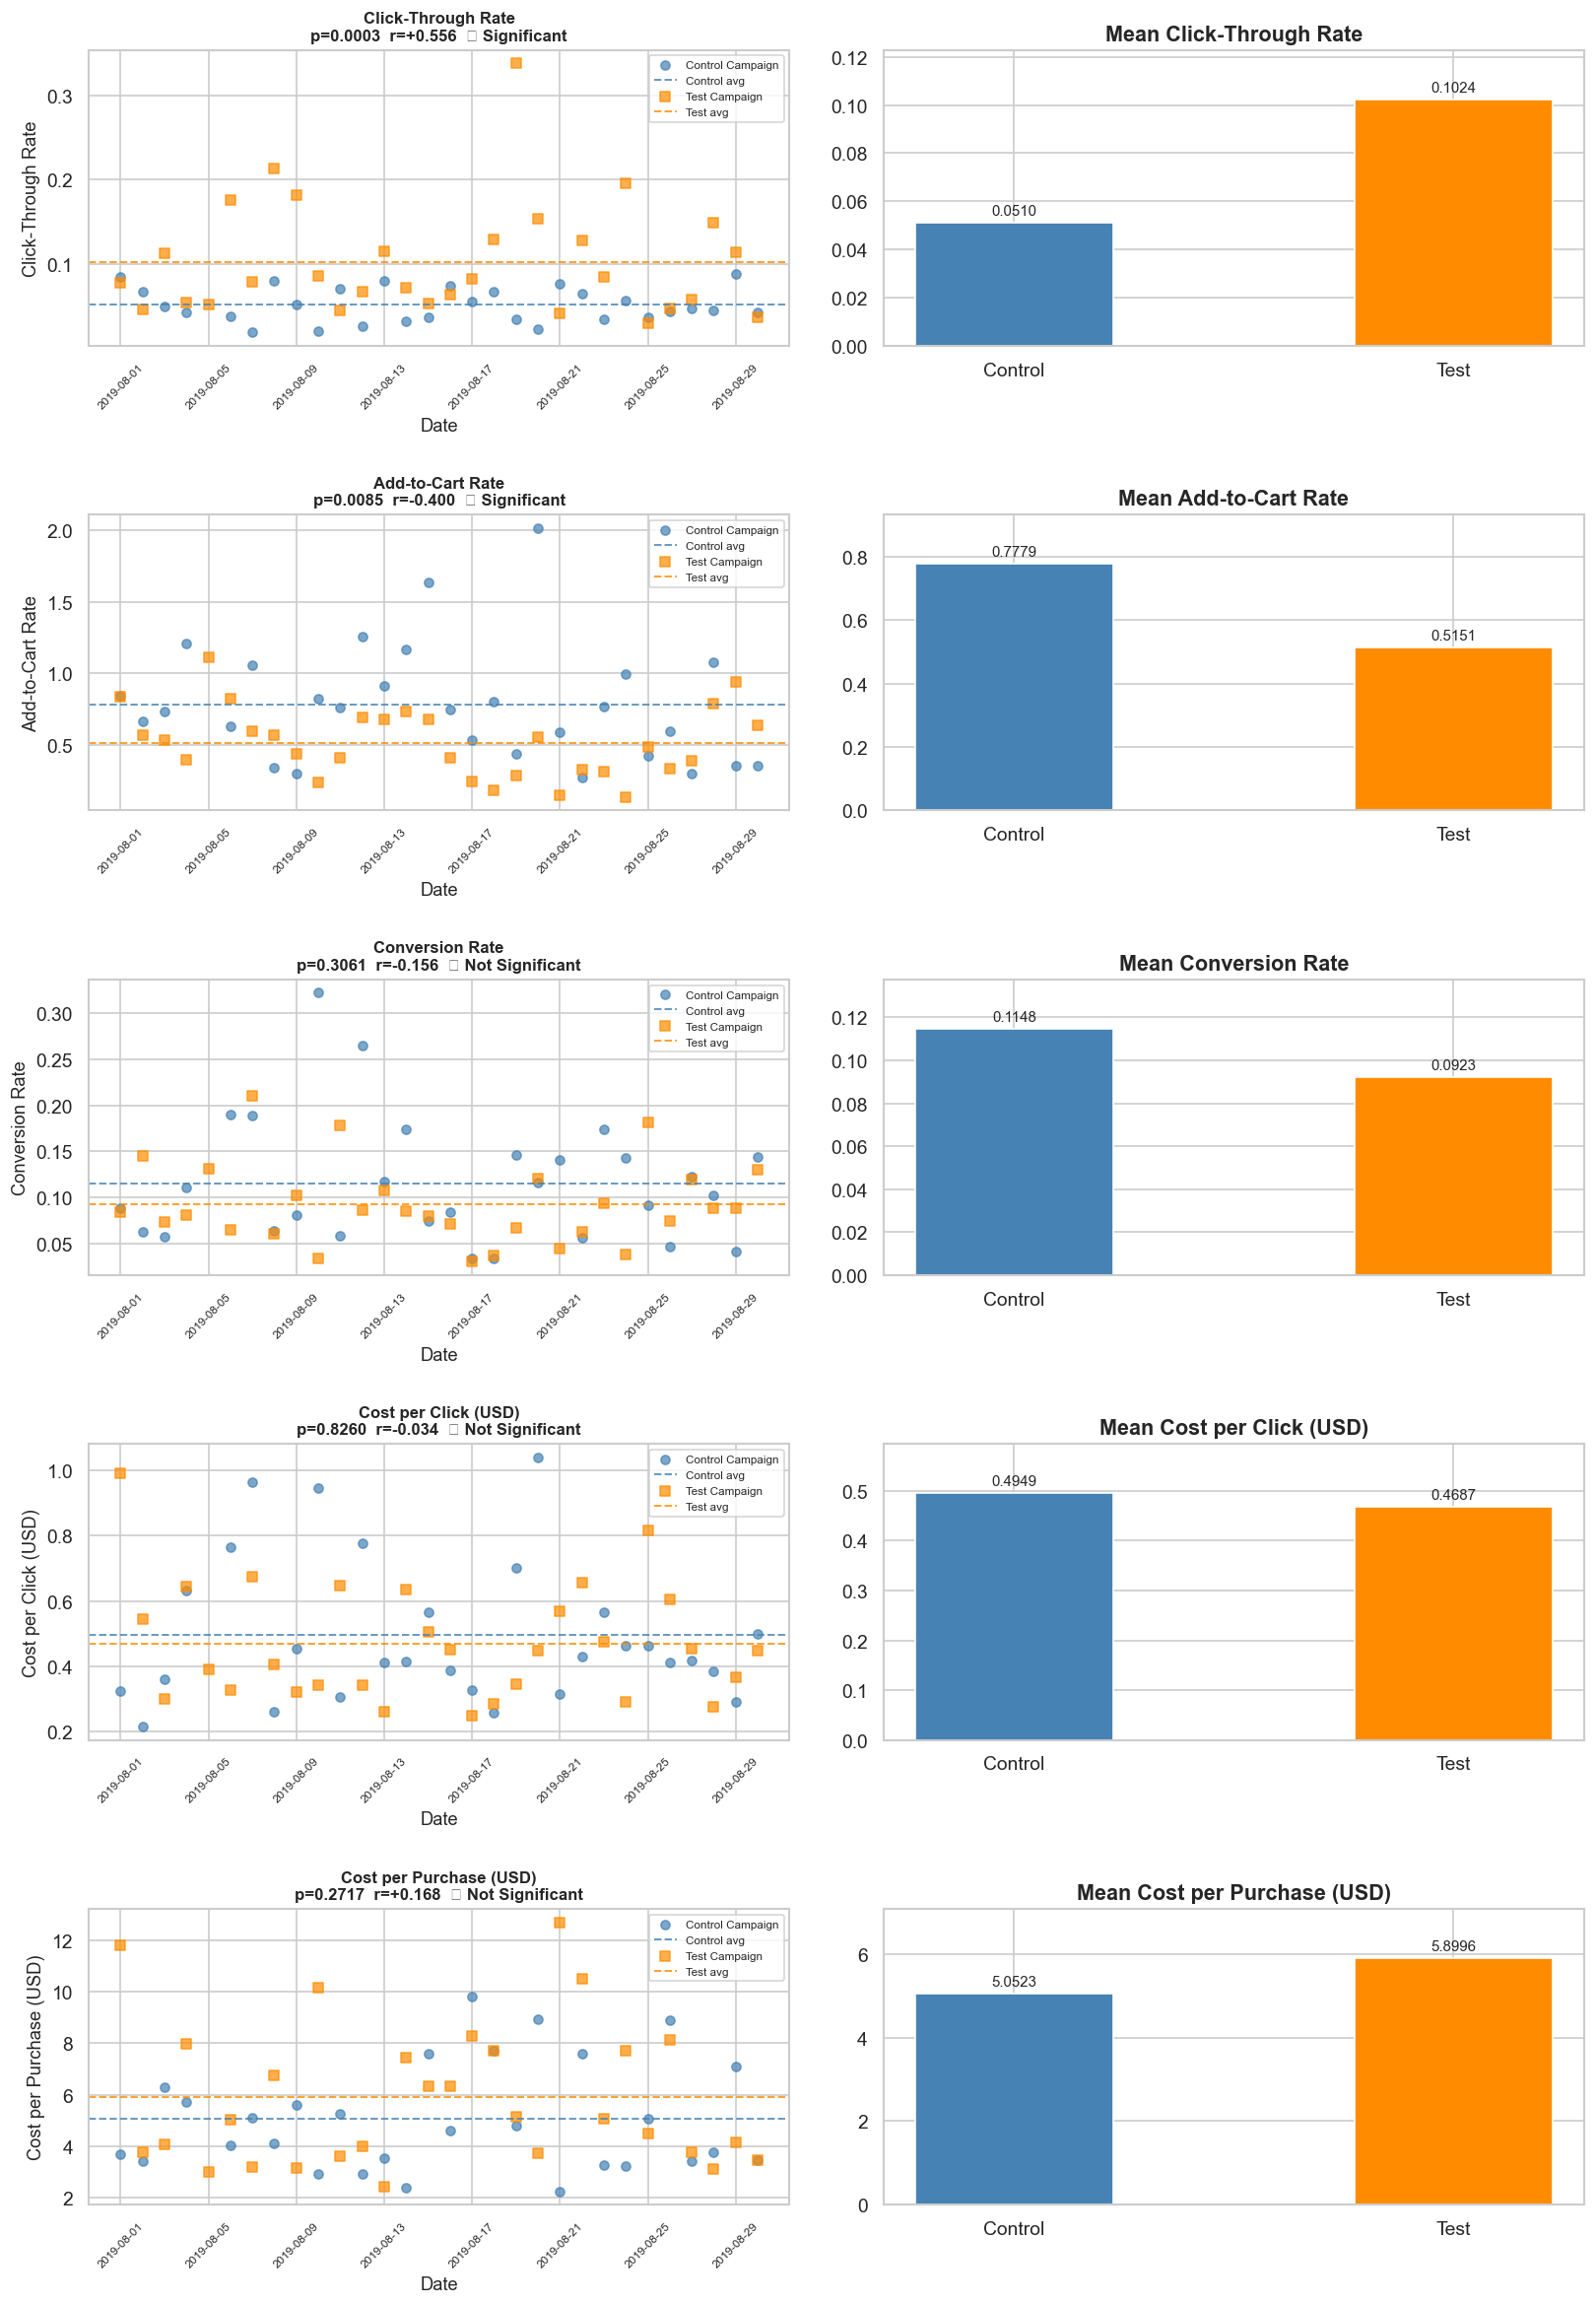

In [46]:
fig, axes = plt.subplots(len(KPIS), 2, figsize=(14, len(KPIS) * 4))

kpi_labels = {
    'CTR': 'Click-Through Rate',
    'Add_to_Cart_Rate': 'Add-to-Cart Rate',
    'Conversion_Rate': 'Conversion Rate',
    'CostperClick': 'Cost per Click (USD)',
    'CostperPurchase': 'Cost per Purchase (USD)'
}

for i, kpi in enumerate(KPIS):
    ax_ts, ax_bar = axes[i]
    label = kpi_labels[kpi]

    for campaign, color, marker in [
        ('Control Campaign', 'steelblue', 'o'),
        ('Test Campaign', 'darkorange', 's')
    ]:
        subset = daily_metrics[daily_metrics['Campaign Name'] == campaign]
        avg = subset[kpi].mean()
        ax_ts.scatter(subset['Date'], subset[kpi], label=campaign,
                      color=color, marker=marker, s=30, alpha=0.7)
        ax_ts.axhline(avg, ls='--', lw=1.2, color=color,
                      alpha=0.8, label=f'{campaign.split()[0]} avg')

    # Annotate significance
    row = results_df[results_df['KPI'] == kpi].iloc[0]
    sig_txt = f'p={row["p-value"]:.4f}  r={row["Effect r"]:+.3f}  {"✅ Significant" if row["Significant"] else "❌ Not Significant"}'
    ax_ts.set_title(f'{label}\n{sig_txt}', fontsize=10)
    ax_ts.set_xlabel('Date')
    ax_ts.set_ylabel(label)
    ax_ts.legend(fontsize=7)
    ax_ts.tick_params(axis='x', rotation=45, labelsize=7)

    # Bar chart: means
    means = [daily_metrics[daily_metrics['Campaign Name'] == c][kpi].mean()
             for c in ['Control Campaign', 'Test Campaign']]
    bars = ax_bar.bar(['Control', 'Test'], means,
                      color=['steelblue', 'darkorange'], edgecolor='white', width=0.45)
    ax_bar.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
    ax_bar.set_title(f'Mean {label}')
    ax_bar.set_ylim(0, max(means) * 1.2)

plt.tight_layout(pad=2)
plt.show()

## 10. Funnel Drop-Off Analysis

Aggregate funnel analysis reveals where each campaign loses users between stages. This is critical context for interpreting the significant CTR and Add-to-Cart Rate differences alongside the non-significant Conversion Rate.

A campaign that improves upper-funnel metrics but fails to convert may indicate:
- Misaligned audience targeting (attracting browsers, not buyers)
- A landing page or checkout experience bottleneck
- Product-market fit issues surfaced at the decision point

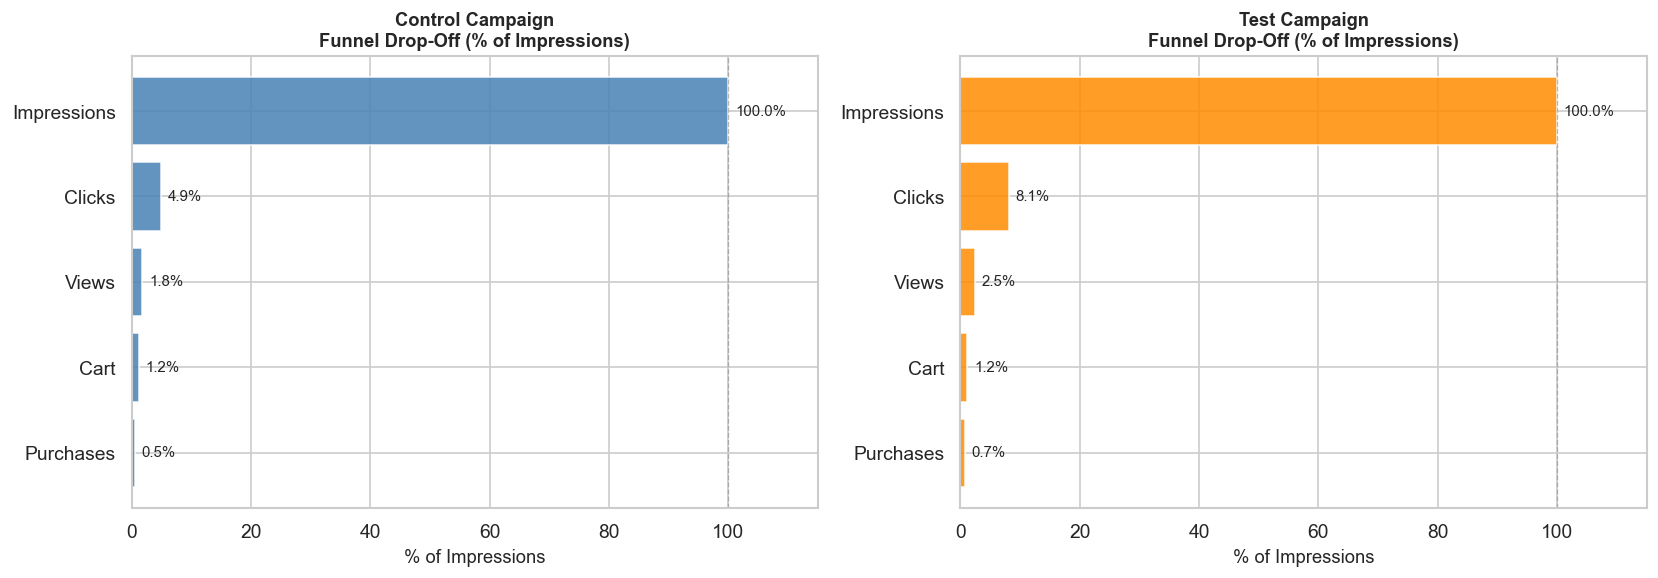

=== Stage-to-Stage Drop-Off Rates ===

Control Campaign
  Impressions → Clicks: 4.9% retained
  Clicks → Views: 36.5% retained
  Views → Cart: 66.9% retained
  Cart → Purchases: 40.2% retained

Test Campaign
  Impressions → Clicks: 8.1% retained
  Clicks → Views: 30.8% retained
  Views → Cart: 47.4% retained
  Cart → Purchases: 59.1% retained


In [49]:
funnel_stages = ['Number of Impressions', 'Website Clicks',
                 'Viewed Content', 'Added to Cart', 'Purchases']
funnel_labels = ['Impressions', 'Clicks', 'Views', 'Cart', 'Purchases']

funnel_data = ab_data.groupby('Campaign Name')[funnel_stages].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, campaign, color in [
    (axes[0], 'Control Campaign', 'steelblue'),
    (axes[1], 'Test Campaign', 'darkorange')
]:
    values = funnel_data.loc[campaign, funnel_stages].values.astype(float)
    pcts = values / values[0] * 100

    bars = ax.barh(funnel_labels[::-1], pcts[::-1],
                   color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', fontsize=9, padding=4)
    ax.set_xlim(0, 115)
    ax.set_title(f'{campaign}\nFunnel Drop-Off (% of Impressions)', fontsize=11)
    ax.set_xlabel('% of Impressions')
    ax.axvline(x=100, ls='--', lw=0.8, color='gray', alpha=0.5)

plt.tight_layout()
plt.show()

# Stage-to-stage drop-off rates
print('=== Stage-to-Stage Drop-Off Rates ===')
for campaign in ['Control Campaign', 'Test Campaign']:
    print(f'\n{campaign}')
    vals = funnel_data.loc[campaign, funnel_stages].values.astype(float)
    for j in range(1, len(funnel_stages)):
        rate = vals[j] / vals[j-1] * 100
        print(f'  {funnel_labels[j-1]} → {funnel_labels[j]}: {rate:.1f}% retained')

## 11. Conclusions & Business Recommendations

### 11.1 Statistical Summary

| KPI | Daily MWU | Pooled z-test | Effect (r) | Interpretation |
|-----|-----------|---------------|------------|----------------|
| CTR | See §9 `results_df` | See §9.1 | Medium | Test drives more clicks per impression |
| Add-to-Cart Rate | See §9 `results_df` | See §9.1 | Medium | Test converts views to cart additions better |
| Conversion Rate | See §9 `results_df` | See §9.1 | Small | No detected difference (see §9.2 for MDE) |
| Cost per Click | See §9 `results_df` | n/a (not a rate) | Small | No detected difference |
| Cost per Purchase | See §9 `results_df` | n/a (not a rate) | Small | No detected difference |

Numbers are intentionally not hard-coded into this table — they are printed by the cells in §9 and §9.1 at run-time so the summary cannot silently drift from the actual output.

### 11.2 Business Interpretation

The Test campaign improves **top- and mid-funnel engagement** — users see the ad and are more likely to click and add items to their cart. However, **this improvement does not cascade to purchases**: we are paying for intent without capturing incremental revenue.

The funnel drop-off analysis pinpoints where the problem occurs — at **Add-to-Cart → Purchase**. This bottleneck is campaign-independent (it exists in both groups), but the Test campaign exposes it more aggressively by pushing more users into cart.

Important caveat, given §9.2: a non-significant conversion rate result at this sample size is consistent with any true lift smaller than the computed MDE. It is *not* proof that the campaigns are equivalent on conversion. If the business needs to claim equivalence (not just absence of a detected difference), an equivalence test (TOST) against a pre-specified margin is the correct tool.

### 11.3 Recommended Actions

1. **Do not scale the Test campaign budget yet.** Higher CTR at the same conversion rate means more spend for equivalent revenue — negative ROI impact.
2. **Investigate the Add-to-Cart → Purchase drop-off.** Audit checkout UX, payment friction, and pricing signals. This is the highest-leverage intervention.
3. **Run a follow-up A/B test on the checkout flow.** Once the conversion bottleneck is addressed, re-run the campaign test to see if CTR and Add-to-Cart gains translate to revenue.
4. **If possible, rerun at user-level granularity.** Daily aggregates are a weak unit of analysis: they are correlated within an arm and waste statistical power relative to per-user randomisation. Use daily aggregates only when user-level data is truly unavailable.

### 11.4 Limitations

- Sample size is moderate (~30 days per group); see §9.2 for the MDE this implies.
- The analysis treats each day as an independent observation; temporal autocorrelation (weekday effects, campaign ramp) is not modelled.
- No user-level data is available; all analysis is at the daily aggregate level, which masks individual variation and understates statistical power.
- Per-day KPIs use mean-of-ratios, which is biased when daily denominators vary. We mitigate this by also reporting pooled (ratio-of-sums) KPIs and running a pooled two-proportion z-test on rate KPIs — that is the estimator the business-level conclusion should rest on.